## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')#completa el código

In [3]:
traffic.head(5)# mostrar las primeras 5 filas de traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
eco.head(5)# mostrar las primeras 5 filas de eco

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [5]:
traffic.info() # Examinar la estructura de traffic


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo ... 
- object

In [6]:
eco.info()# Examinar la estructura de eco


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, ...
- object 

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:
# Estandarizar los nombres de las columnas de traffic
traffic.rename(columns={'Country': 'country','UpdateTimeUTC':'update_time_utc'}, inplace=True) #tu código aquí

# verificar cambios
traffic.columns

Index(['country', 'City', 'update_time_utc', 'JamsDelay', 'TrafficIndexLive',
       'JamsLengthInKms', 'JamsCount', 'TrafficIndexWeekAgo',
       'UpdateTimeUTCWeekAgo', 'TravelTimeLivePer10KmsMins',
       'TravelTimeHistoricPer10KmsMins', 'MinsDelay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
eco.rename(columns={'Country': 'country','UpdateTimeUTC':'update_time_utc'}, inplace=True) #tu código aquí

# verificar cambios
eco.columns

Index(['Year', 'City', 'country', 'City GDP/capita', 'Unemployment %',
       'PM2.5 (μg/m³)', 'Population (M)'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')#tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['UpdateTimeUTCWeekAgo'], errors='coerce')#tu código aquí

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   country                         1004464 non-null  object        
 1   City                            1004464 non-null  object        
 2   update_time_utc                 1004464 non-null  datetime64[ns]
 3   JamsDelay                       1004464 non-null  float64       
 4   TrafficIndexLive                1004464 non-null  float64       
 5   JamsLengthInKms                 1004464 non-null  float64       
 6   JamsCount                       1004464 non-null  float64       
 7   TrafficIndexWeekAgo             1004464 non-null  float64       
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object        
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64       
 10  TravelTimeHistoricPer10KmsMins  1004464 no

In [10]:
# Limpia separadores y convierte columnas numéricas en eco

eco['city_gdp_capita'] = eco['City GDP/capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['Unemployment %'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['Population (M)'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = (eco['population_m']*1000000)

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              30 non-null     int64  
 1   City              30 non-null     object 
 2   country           30 non-null     object 
 3   City GDP/capita   30 non-null     object 
 4   Unemployment %    30 non-null     object 
 5   PM2.5 (μg/m³)     30 non-null     object 
 6   Population (M)    30 non-null     object 
 7   city_gdp_capita   30 non-null     float64
 8   unemployment_pct  30 non-null     float64
 9   population_m      30 non-null     float64
 10  population        30 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 2.7+ KB


,Year,City,country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M),city_gdp_capita,unemployment_pct,population_m,population
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30",15782.0,6.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50",14475.0,9.1,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60",13142.0,9.8,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:

# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year
traffic = traffic[traffic['year'] == 2024] 
# Verificar cambio
traffic.head(3)


,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,update_time_utc_week_ago,year
302,ARE,abu-dhabi,2024-12-31 23:01:30,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024-12-24 23:01:30.001,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024-12-24 22:01:30.000,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024-12-24 21:01:30.000,2024


In [12]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024]
eco_2024 = eco[eco['Year']==2024]

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,City,update_time_utc,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,update_time_utc_week_ago,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024-12-24 23:01:30.001,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024-12-24 22:01:30.000,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024-12-24 21:01:30.000,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024-12-24 20:01:30.001,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024-12-24 19:01:00.000,2024


,Year,City,country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M),city_gdp_capita,unemployment_pct,population_m,population
15,2024,buenos-aires,Argentina,"18.117,00",7.2%,"14,50","15,40",18117.0,7.2,15.4,15400000.0
16,2024,sao-paulo,Brazil,"14.703,00",8.5%,"28,00","22,60",14703.0,8.5,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,"13.349,00",9.2%,"18,40","13,70",13349.0,9.2,13.7,13700000.0
18,2024,brasilia,Brazil,"16.251,00",7.8%,"12,80","4,80",16251.0,7.8,4.8,4800000.0
19,2024,salvador,Brazil,"8.899,00",12.4%,"15,20","3,90",8899.0,12.4,3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [13]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic.groupby(['City', 'country', 'year']).agg(['mean']).reset_index()



# Mostrar resultado
traffic_city_year_2024.head()

,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
,,,,mean,mean,mean,mean,mean,mean,mean,mean
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,15.821025,16.267977,15.493804,0.774172
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,21.874836,13.397861,12.604894,0.792968
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,17.445227,15.219292,14.724016,0.495276
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,14.295209,9.829092,9.689328,0.139764
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,22.508810,15.879694,14.749945,1.129749


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [14]:
# Recrear el DataFrame con columnas limpias
traffic_city_year_2024 = traffic.groupby(['City', 'country', 'year']).agg({
    'JamsDelay': 'mean',
    'TrafficIndexLive': 'mean',
    'JamsLengthInKms': 'mean',
    'JamsCount': 'mean',
    'TravelTimeLivePer10KmsMins': 'mean',
    'TravelTimeHistoricPer10KmsMins': 'mean',
    'MinsDelay': 'mean'
}).reset_index()

# Verificar las columnas
print("Columnas corregidas:")
print(traffic_city_year_2024.columns.tolist())
traffic_city_year_2024.sort_values(["JamsDelay"], ascending=False).head(10)


Columnas corregidas:
['City', 'country', 'year', 'JamsDelay', 'TrafficIndexLive', 'JamsLengthInKms', 'JamsCount', 'TravelTimeLivePer10KmsMins', 'TravelTimeHistoricPer10KmsMins', 'MinsDelay']


,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,21.809092,19.953550,1.855542
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,22.443778,21.745626,0.698152
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,18.505043,17.108691,1.396351
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,17.714139,16.388979,1.325160
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,27.134629,24.664734,2.469894
321,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,20.801836,19.672810,1.129026
156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,19.982495,17.518796,2.463699
159,jakarta,IDN,2024,1379.037135,30.419242,215.228820,295.492817,18.098409,16.905109,1.193300
268,paris,FRA,2024,1320.746822,29.313446,265.865975,324.405534,17.658980,16.488097,1.170884
201,los-angeles,USA,2024,1277.210458,30.446623,341.053551,321.732026,13.429048,12.638155,0.790893


La ciudad con el mayor tiempo promedio de tráfico es ... mexico-city


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [15]:
print("Columnas disponibles en traffic_city_year_2024:")
print(traffic_city_year_2024.columns.tolist())

# Seleccionar columnas clave de tráfico y economía

left_cols = ['City', 'country', 'year', 'JamsDelay', 'TrafficIndexLive',
             'JamsLengthInKms', 'JamsCount', 'TravelTimeLivePer10KmsMins',
             'TravelTimeHistoricPer10KmsMins', 'MinsDelay']

right_cols = ['City','Year','city_gdp_capita','unemployment_pct','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco[right_cols].copy()

# Renombrar la columna Year a year en eco

eco_2024_small = eco[['City','Year','city_gdp_capita','unemployment_pct','population']].copy()
eco_2024_small.rename(columns={'Year': 'year'}, inplace=True)


# Unir datasets
merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['City', 'year'],
    how='inner'
)

# Mostrar las primeras 5 filas
merged.head()

Columnas disponibles en traffic_city_year_2024:
['City', 'country', 'year', 'JamsDelay', 'TrafficIndexLive', 'JamsLengthInKms', 'JamsCount', 'TravelTimeLivePer10KmsMins', 'TravelTimeHistoricPer10KmsMins', 'MinsDelay']


,City,country,year,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,city_gdp_capita,unemployment_pct,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,18.304538,17.817311,0.487228,11124.0,9.5,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,24.992185,23.292557,1.699628,11442.0,10.0,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,13.338658,13.145216,0.193442,16251.0,7.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,17.907916,17.491349,0.416566,18117.0,7.2,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,17.258700,17.118736,0.139965,12381.0,8.2,3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

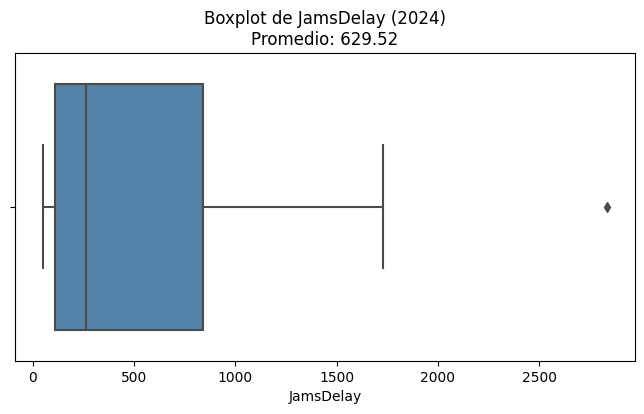

In [16]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 4))

sns.boxplot(
    data=merged,
    x='JamsDelay',
    color='steelblue'
)


# obtener promedio para mostrarlo en título
mean_value = merged['JamsDelay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


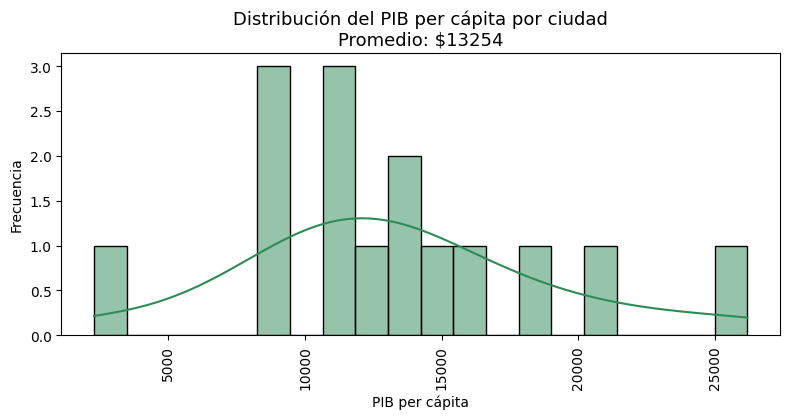

In [17]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.histplot(
    data=merged,
    x='city_gdp_capita',
    bins=20,
    kde=True,
    color='seagreen'
)

# Calcular promedio
mean_gdp = merged['city_gdp_capita'].mean()

plt.title(f'Distribución del PIB per cápita por ciudad\nPromedio: ${mean_gdp:.0f}', fontsize=13)



plt.xlabel('PIB per cápita')
plt.ylabel('Frecuencia')



plt.tight_layout()
plt.xticks(rotation=90)
plt.show()


In [18]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])

plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [19]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.

**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?


##Resumen ejecutivo

**Contexto & objetivo:** 
No existe una relación entre movilidad urbana y productividad económca .    

Variables clave utilizadas y su relevancia

Variables de movilidad urbana

JamsDelay: Impacto total del tráfico en tiempo perdido. Es un indicador directo del costo social y económico de la congestión.
    
TrafficIndexLive: Refleja la intensidad del tráfico en tiempo real.
    
TravelTimeLivePer10KmsMins: Captura la experiencia real del usuario; afecta calidad de vida y eficiencia operativa.
    

Variables de productividad económica

city_gdp_capita: Dato del nivel de desarrollo económico y productividad promedio.
    
population: Ayuda a contextualizar la presión sobre infraestructura urbana.
    
unemployment_pct: Indica el uso efectivo del capital humano.

Relevancia:
Las variables descritas arriba nos indican acompañamiento del crecimiento económico y la infrestructura de la cuidad para soportar un mayor crecimiento en el futuro.

**Cobertura de datos:**
- Año analizado: 2024
- Ciudades: Se analizan 15 ciudades latinoamericanas en 7 países diferentes.
- Variables: movilidad urbana vs productividad económica

**Metodología:**
Se trabajó con 2 datasets, Traffic Index  y OECD Cities, movilidad y economía.
Para obrener nuestro resultado en una sola tabla:
Estandarizamos columnas a formato snake_case, seguido de columnas que contienen fechas fueron convertidas  a formato datetime, 
las variables económicas se limpiaron y estandarizaron, calculamos la población en millones de habitantes y estrajimos el año de las fechas para permitir un análisis concreto.
Dado que el dataset contiene millones de registros fue necesario agrupar por ciudad, país y año, calculando los promedioas anuales de los principales indicadores de movilidad.
Posteriormente se realizó la unión de ambos datasets  con INNER JOIN.las claves de unión fueron las columnas City y year presentes en ambos datasets.

Validaciones visuales:
Para validar la calidad de los datos y explorar patrones utilizamos:
Boxplots  jams_delay para variables de congestión, de esta manera 
Evaluamos la dispersión.
Identificamos valores atípicos (outliers) relevantes, como megaciudades con congestión extrema.
Histogramas de indicadores económicos (PIB per cápita) para:
Analizar la forma de la distribución.
Detectar sesgos y concentraciones alrededor del promedio.
Revisión de tendencias generales mediante gráficos comparativos, 
    
**Hallazgos clave:**
En este ánlisis podemos observar los siguientes puntos:
- En ciudades gran población tienden a incrementar la congestión urbana. 
- Existen ciudades de alto PIB per cápita que mantienen niveles elevados de congestión, lo que sugiere que el desarrollo económico por sí solo no garantiza una movilidad eficiente.
- PIB no influye totalmente en el tráfico ya que en el caso de Montevideo encontramos el PIB más alto de la región y la congestión urbana más baja.

 **Anomalías u outliers relevantes**
 -Megaciudades como Ciudad de México y São Paulo aparecen como outliers claros en congestión, con valores extremadamente altos de JamsDelay y longitud de embotellamientos, independientemente de su nivel de PIB per cápita. Estas ciudades dominan los extremos superiores de las distribuciones y podrían sesgar análisis globales si no se tratan por separado.
 - Algunas ciudades latinoamericanas muestran una combinación crítica de alta congestión y PIB per cápita relativamente bajo, específicamente ciudades de Brasil y Colombia, lo que las posiciona como casos prioritarios para intervención en infraestructura de transporte.
 - Se sugiere revisar el caso de Montevideo para implementar proyectos económicos que ser replicados en LATAM, ya que se identifica como un caso de éxito donde la congestión de movilidad y población baja no repercute en el ingreso per cápita del ciudadano. Obteniendo una mayor calidad de vida.
   

**Recomendaciones:**

Bogotá emerge como la ciudad prioritaria para inversión en infraestructura de transporte , seguido de Lima y Buenos Aires. Esto debido a la combinación más crítica de:

Altos niveles de congestión vehicular, Bogotá presenta valores elevados de JamsDelay (1141), JamsLengthInKms(140) y JamsCount (230), ubicándose en la parte alta de la distribución de congestión dentro del dataset.

PIB per cápita relativamente bajo
En comparación con Buenos Aires y con grandes ciudades , Bogotá mantiene un nivel de PIB per cápita sensiblemente menor, lo que refuerza la hipótesis de que la congestión está actuando como un freno estructural a la productividad económica.

**Sugerencias de Inversión:**
- Desarrollar un sistame confiable de transporte público en ciudades donde el PIB es alto, casos como el de Ciudad de México, Buenos Aires Brasilia y Sao Paulo.
- Atraer y difundir inversión de corredores de bicicletas así como el uso de bicicleta para la movilidad de la población económicamente activa en las ciudades previamente dichas.

**Requerimiento de algún análisis adicional**
- Confirmar si la relación observada en 2024 es similar a la actividad de años anteriores.
- Evaluar congestión y productividad por zonas dentro de la ciudad, ya que los promedios pueden ocultar desigualdades territoriales importantes debido a la ubicación de los centros de trabajo.
- Hacer una comparativa independiente para grandes ciudades ( Ciudad de México y Sao Paulo), ya que la referencia y la data no es la misma a las diferentes ciudades de la región.























    